[Chapter 7] Target Transformation for Time Series Forecasting

In [13]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [8]:
# generate synthetic ts data

length = 100
index = pd.date_range(start="2021-11-03", periods=length)

# White Noise
y_random = pd.Series(np.random.randn(length), index=index)

# White Noise
y_random_2 = pd.Series(np.random.randn(length), index=index)

# White Noise+Trend
_y_random = pd.Series(np.random.randn(length), index=index)
t = np.arange(len(_y_random))
y_trend = _y_random+t*_y_random.mean()*0.8

# Heteroscedastic
_y_random = pd.Series(np.random.randn(length), index=index)
t = np.arange(len(_y_random))
y_hetero = (_y_random*t)

#WhiteNoise + Seasonal
_y_random = pd.Series(np.random.randn(length), index=index)
t = np.arange(len(_y_random))
y_seasonal = (_y_random+1.9*np.cos((2*np.pi*t)/(length/4)))

#unit root
_y_random = pd.Series(np.random.randn(length), index=index)
y_unit_root = _y_random.cumsum()

plot_df = pd.DataFrame({"Time":np.arange(100),"Timeseries 1": y_random, "Timeseries 2": y_trend, \
                            "Timeseries 3": y_hetero, "Timeseries 4": y_unit_root, "Timeseries 5": y_seasonal, \
                                "Timeseries 6": y_random_2})

detecting and correcting for unit roots

In [ ]:
# detecting unit root

# y_t = phi*y_{t-1} + epislon_t
# phi > 1: increasing/decreasing trend
# phi < 1: stationary (mean of the series tends to zero)
# phi = 1: random walk


# the augmented dickey-fuller (adf) test (check for unit root)
# H0: phi = 1 vs. H1: phi < 1
from statsmodels.tsa.stattools import adfuller
result = adfuller(y_unit_root)
print(result) # p-value = 0.388 => cannot reject the H0 that ts is a unit root


# with easier format
from src.transforms.stationary_utils import check_unit_root

result = check_unit_root(y_unit_root, confidence=0.05)
print(f"\nStationary: {result.stationary} | p-value: {result.results[1]}")

(-1.784282382251492, 0.38829250074226607, 0, 99, {'1%': -3.498198082189098, '5%': -2.891208211860468, '10%': -2.5825959973472097}, 262.8463767523343)

Stationary: False | p-value: 0.38829250074226607


ADF_Test(stationary=True, results=(-11.303331819298933, 1.2912954413899335e-20, 0, 98, {'1%': -3.4989097606014496, '5%': -2.891516256916761, '10%': -2.5827604414827157}, 258.7696778784267))


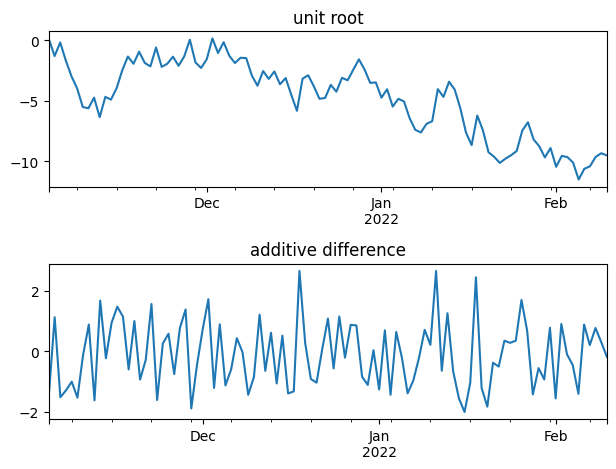

In [ ]:
# correcting unit root

# differencing transform, to make a ts stationary (at least transform a unit root to stationary) 
# multiplicative transfomer to transform by y_{t}/y_{t-1}
from src.transforms.target_transformations import AdditiveDifferencingTransformer, MultiplicativeDifferencingTransformer


# call differencing transformer
diff_transformer = AdditiveDifferencingTransformer()
# [1:] because differencing reduces the lenght of the time series by one
y_diff = diff_transformer.fit_transform(y_unit_root)[1:]
# check if diff is stationary
print(check_unit_root(y_diff))


# plot
fig, axs = plt.subplots(2)
y_unit_root.plot(title="unit root",ax=axs[0])
y_diff.plot(title="additive difference",ax=axs[1])
plt.tight_layout()
plt.show()

detecting and correcting for trend -  deterministic and stochastic trends

In [19]:
# generate 2 ts with trends
def generate_autoregressive_series(length, phi):
    x_start = np.random.uniform(-1, 1)
    y = []
    for i in range(length):
        t = x_start*phi+np.random.uniform(-1, 1)
        y.append(t)
        x_start = t
    return np.array(y)

length=100

# ar(1) with phi=1.05
ar_series = generate_autoregressive_series(length, phi=1.05)

# linear trend
beta_0 = 0.5
beta_1 = 0.1
x = np.arange(length)
y_trend = beta_0 + beta_1*x + np.random.rand(length)

In [ ]:
# detect trend - check_determinstic_trend
from src.transforms.stationary_utils import check_deterministic_trend

res = check_deterministic_trend(ar_series)
print(f"Stationary: {res.adf_res.stationary} | Deterministic Trend: {res.deterministic_trend}")

res = check_deterministic_trend(y_trend)
print(f"Stationary: {res.adf_res.stationary} | Deterministic Trend: {res.deterministic_trend}")

Stationary: False | Deterministic Trend: False
Stationary: False | Deterministic Trend: False


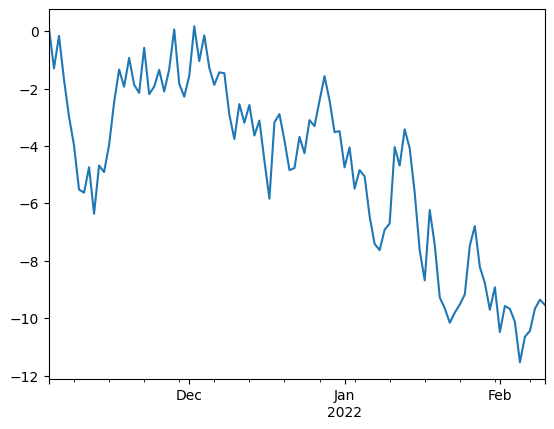

-0.6084848484848486 2.962782659253143e-19
Kendalls Tau: Trend: True | Direction: decreasing | Deterministic: False
Mann-Kendalls: Trend: True | Direction: decreasing | Deterministic: False


In [ ]:
# detect trend - check trend (presence of a monotonic upward or downward trend)
from src.transforms.stationary_utils import check_trend

# plot
y_unit_root.plot()
plt.show()

# kendall's tau
# non-parametric test (no assumption on data) as a measure of correlation (carried out on the ranks of data)
import scipy.stats as stats
tau, p_value = stats.kendalltau(y_unit_root, np.arange(len(y_unit_root)))
# tau=0 shows no relationship and 1 or -1 is a perfect relationship
print(tau, p_value)
# tau=-0.6 

kendall_tau_res = check_trend(y_unit_root, confidence=0.05)
print(f"Kendalls Tau: Trend: {kendall_tau_res.trend} | Direction: {kendall_tau_res.direction} | Deterministic: {kendall_tau_res.deterministic}")


# mann-kendall test (m-k test)
# non-parametric test by analyzing the signs between consecutive points in the time series
# assumption: no auto-correlation in ts, no seasonality in the ts
mann_kendall_res = check_trend(y_unit_root, confidence=0.05, mann_kendall=True)
print(f"Mann-Kendalls: Trend: {mann_kendall_res.trend} | Direction: {mann_kendall_res.direction} | Deterministic: {mann_kendall_res.deterministic}")

In [ ]:
# detrending transform

# TO COTINUE (page 192)